In [2]:
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
import numpy as np
from scipy.integrate import quad
import random
import pandas as pd
from sympy import Symbol,integrate,exp,cos,sin,I,simplify
import seaborn as sns
from multiprocess import Pool
import matplotlib.pylab as pl
import ot
import ot.plot
from scipy.spatial import distance
from sklearn.preprocessing import normalize
import time
from OptimizeTest import compute_CS_grid, sample_tagged_times_ij, inside_dalitz

Gd=1.61e-6 #(MeV)
Grho=147.4 #(MeV)
md=1864.84
mrho=775.26
mpi0=135
mpi=140

gamma = 147.4         # MeV from rho
dm = 2.11e-9          # 0.51 ps^-1
m = 770
m_b = 5280
m_pi = 135

M   = m_b      # your B mass
m1  = mpi      # pi+
m2  = mpi      # pi-
m3  = mpi0     # pi0

x_grid = np.linspace(0, 40, 30000)  # ps (for plotting/reference)
Gamma = 2.746e-9 #MeV
Delta_m = 2.11e-9          # MeV
T=2*np.pi/Delta_m
r= Delta_m*T
s= T*Gamma
C=0.3
S=0.4
x_max =10
n_iter = 100
N_evt = 1000

C_dist = np.array(np.load("list of c.npy", allow_pickle = True), dtype = object)
S_dist = np.array(np.load("list of s.npy", allow_pickle = True), dtype = object)

cpvc_dist = np.load("optimised_C_emd.npy")
cpvs_dist = np.load("optimised_S_emd.npy")

x_plus  = np.arange((2*mpi)**2/M**2, (m_b-mpi)**2/M**2, Grho/(4*M))
def E2_star(S_plus):
    return np.emath.sqrt(S_plus)/2
def E3_star(S_plus):
    return (M**2 - S_plus - mpi**2)/(2*np.emath.sqrt(S_plus))

def s_minus_min(s_plus):
    return (E2_star(s_plus)+E3_star(s_plus))**2 - (np.emath.sqrt((E2_star(s_plus))**2-mpi**2) + (np.emath.sqrt((E3_star(s_plus))**2-mpi**2)))**2

def s_minus_max(s_plus):
    return (E2_star(s_plus)+E3_star(s_plus))**2 - (np.emath.sqrt((E2_star(s_plus))**2-mpi**2) - (np.emath.sqrt((E3_star(s_plus))**2-mpi**2)))**2

x_plus  = np.arange((2*mpi)**2/M**2, (m_b-mpi)**2/M**2, Grho/(4*M))
s2_min = min(s_minus_min(x_plus*M**2))/M**2
s2_max = max(s_minus_max(x_plus*M**2))/M**2

x_minus = np.arange(s2_min, s2_max, Grho/(4*M))

X_plus, X_minus = np.meshgrid(x_plus, x_minus)

s_plus = X_plus * M**2
s_minus = X_minus * M**2
orig_dim = len(x_plus)

cz = np.mean(cpvc_dist)*np.ones((orig_dim, orig_dim))/(orig_dim)
cz = cz.ravel()
sz = np.mean(cpvs_dist)*np.ones((orig_dim, orig_dim))/(orig_dim)
sz = sz.ravel()


cz2 = np.ones_like(X_plus)
cz2 = cz2.ravel()
sz2 = np.ones_like(X_plus)
sz2 = sz2.ravel()


x, acc = sample_tagged_times_ij(n_iter, N_evt, np.mean(cz), np.mean(sz) , 1, x_max, rng=None)
x = np.mean(x.ravel()) 

pz = np.exp(-s*x)*(1+cz*np.cos(r*x)+sz*np.sin(r*x))
pz2 = np.exp(-s*x)*(1+cz2*np.cos(r*x)+sz2*np.sin(r*x))

cpc_p = np.exp(-s*x)*(1+C_dist*np.cos(r*x)+S_dist*np.sin(r*x))
cpv_p = np.exp(-s*x)*(1+cpvc_dist*np.cos(r*x)+cpvs_dist*np.sin(r*x))

mask1 = np.zeros_like(X_plus, dtype=bool)

for i in tqdm(range(len(s_minus))):
    for j in range(len(s_plus)):
        if not inside_dalitz(s_plus[i,j], s_minus[i,j], M, m1, m2, m3):
            mask1[i,j] = True
mask1 = mask1.ravel()
orig_dim = len(x_plus)
print(mask1.shape)

cpc_p_mask = np.zeros(100, dtype= object)
pz_mask = pz[~mask1].ravel()
pz2_mask = pz2[~mask1].ravel()

for i in range(100):
    cpc_p_mask[i] = cpc_p[i].ravel()[~mask1]
    cpc_p_mask[i] = (cpc_p_mask[i]/np.sum(cpc_p_mask[i]))
cpv_p_mask = cpv_p.ravel()[~mask1]

print("Sucesssful masking")

pz_mask = pz_mask/np.sum(pz_mask)
pz2_mask = pz2_mask/np.sum(pz2_mask)
print(np.sum(pz_mask), np.sum(pz2_mask))
cpv_p_mask = (cpv_p_mask/np.sum(cpv_p_mask))

(68,) (68,) (68, 68) (68, 68)


100%|████████████████████████████████████████| 136/136 [00:01<00:00, 106.30it/s]

(18496,)
Sucesssful masking
1.0000000000000002 0.9999999999999998


In [9]:
coords_s = np.stack([X_plus.ravel()[~mask1], X_minus.ravel()[~mask1]], axis=1)
M= ot.dist(coords_s, coords_s)

In [30]:
G=np.zeros(100)
for i in tqdm(range(100)):
    G[i] = ot.emd2(pz_mask, cpc_p_mask[i].ravel(), M, numItermax = 400000)
np.save("Probability Distribution EMD.npy", G)

(9891, 9891) (9891,) (9891,)
1.0000000000000002 1.0


100%|███████████████████████████████████████| 100/100 [1:02:12<00:00, 37.33s/it]


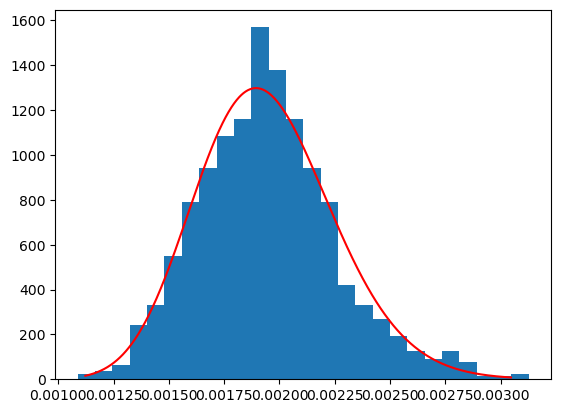

(np.float64(0.001943574400533673), np.float64(9.649667333671305e-08)) 1.0


In [127]:
emds_c = np.load("list of emds_cnz.npy", allow_pickle = True)
"""
fig1, ax1 = plt.subplots(1, 1, figsize=(10,8))
plt.title(r'Null Hypothesis')
ax1.set_ylabel(r"$Count$")
ax1.set_xlabel(r"$EMD$")
plt.hist(emds_c, bins='auto', range=None, density=True, weights=None)
#plt.savefig("NullHyp.png")
"""
import scipy.stats as stats
import matplotlib.pyplot as plt
plt.hist(emds_c, bins='auto', density=True, alpha = 1.0)
df, loc, scale = stats.chi2.fit(emds_c, floc = 0)
xmin, xmax = plt.xlim()
x = np.linspace(stats.chi2.ppf(0.001, df, loc, scale), stats.chi2.ppf(0.999, df, loc, scale), 1000)
p = stats.chi2.pdf(x, df, loc, scale)
#x = np.linspace(xmin, xmax, 1000)
#print(x)
plt.plot(x, p, 'r-')
plt.show()

print(stats.chi2.stats(df, loc, scale, moments='mv'), 1 - stats.chi2.cdf(0.0016, df))

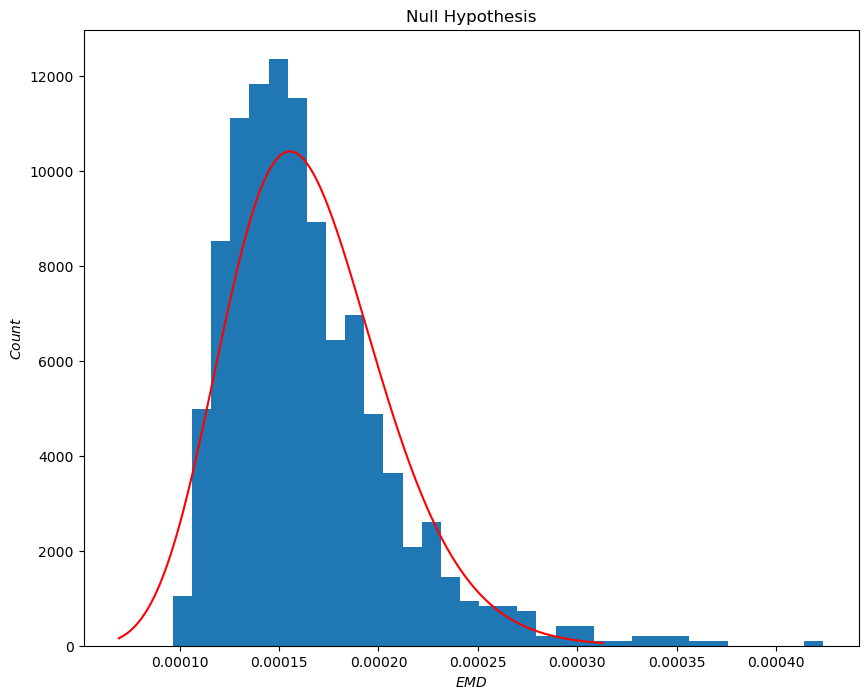

1.0


In [128]:
emds_s = np.load("list of emds_snz.npy", allow_pickle = True)
fig1, ax1 = plt.subplots(1, 1, figsize=(10,8))
plt.title(r'Null Hypothesis')
ax1.set_ylabel(r"$Count$")
ax1.set_xlabel(r"$EMD$")
#plt.hist(emds_s, bins=10, range=None, density=True, weights=None)
#plt.savefig("NullHyp.png")

import scipy.stats as stats
import matplotlib.pyplot as plt
df, loc, scale = stats.chi2.fit(emds_s, floc = 0)
plt.hist(emds_s, bins='auto', density=True)
xmin, xmax = plt.xlim()
x = np.linspace(stats.chi2.ppf(0.001, df, loc, scale), stats.chi2.ppf(0.999, df, loc, scale), 1000)
p = stats.chi2.pdf(x, df, loc, scale)
#x = np.linspace(xmin, xmax, 1000)
#print(x)
plt.plot(x, p, 'r-')
plt.show()

print(1 - stats.chi2.cdf(0.0016, df))

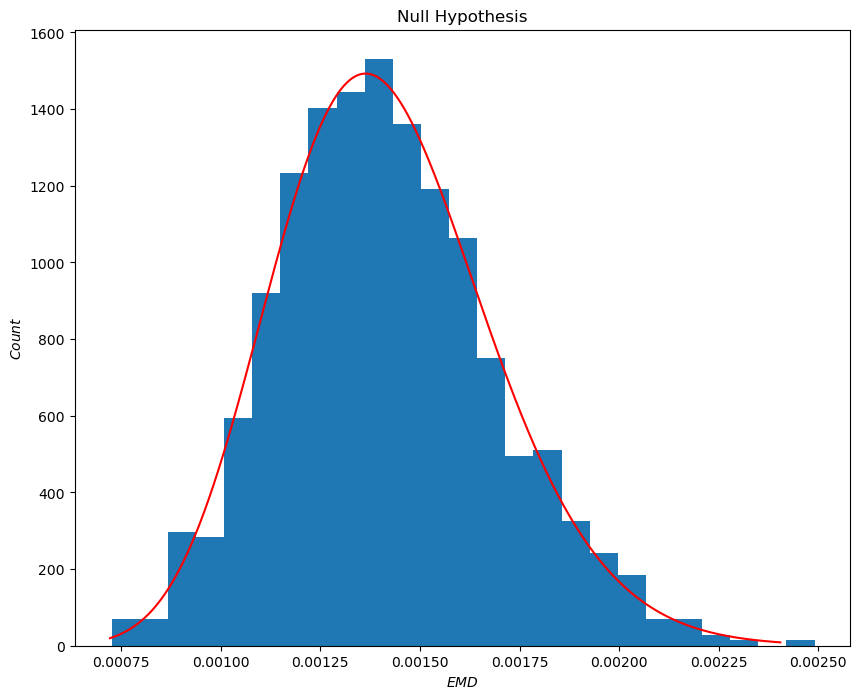

In [117]:
emds_cs = np.load("list of emds_csnz.npy", allow_pickle = True)
fig1, ax3 = plt.subplots(1, 1, figsize=(10,8))
plt.title(r'Null Hypothesis')
ax3.set_ylabel(r"$Count$")
ax3.set_xlabel(r"$EMD$")
#plt.hist(emds, bins=10, range=None, density=None, weights=None)
#plt.savefig("NullHyp.png")

import scipy.stats as stats
import matplotlib.pyplot as plt
df, loc, scale = stats.chi2.fit(emds_cs, floc = 0)
plt.hist(emds_cs, bins='auto', density=True)
xmin, xmax = plt.xlim()
x = np.linspace(stats.chi2.ppf(0.001, df, loc, scale), stats.chi2.ppf(0.999, df, loc, scale), 1000)
p = stats.chi2.pdf(x, df, loc, scale)
#x = np.linspace(xmin, xmax, 1000)
#print(x)
plt.plot(x, p, 'r-')
plt.show()

Chi-squared fit:  df = 54.3843,  scale = 0.000026,  loc = 0.000000
Goodness of fit:  chi2 = 10.2922,  dof = 16,  p = 0.8509


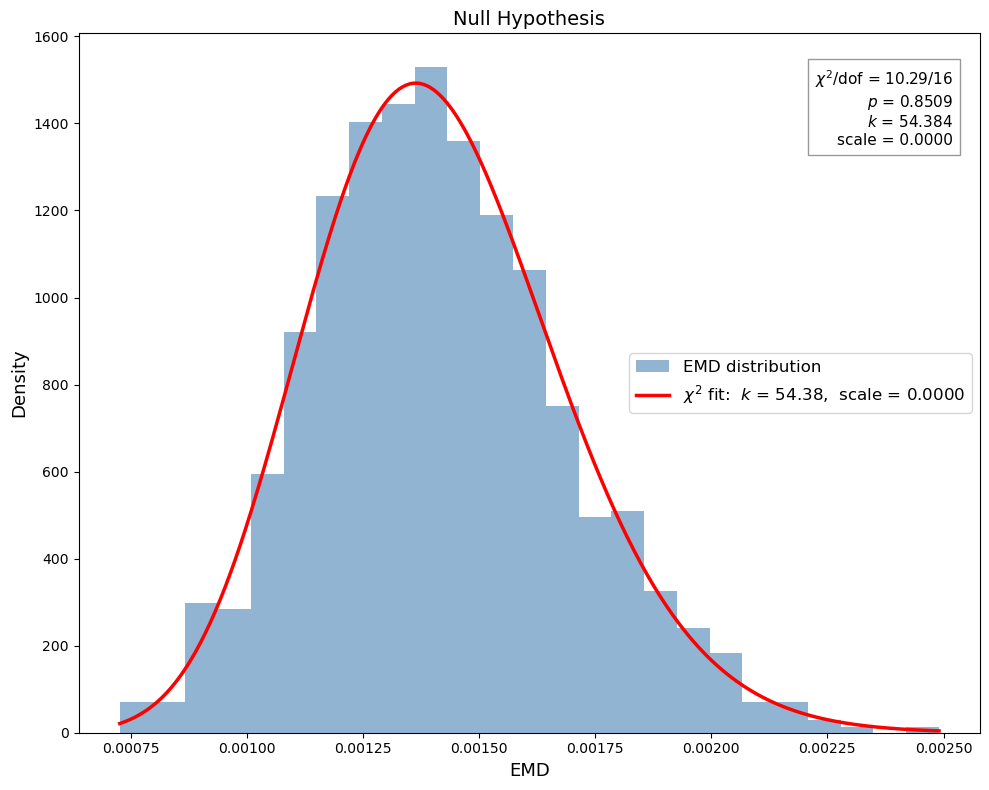

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit

# ── Chi-squared fit ─────────────────────────────────────────────────────────
# Chi-squared PDF: f(x; k) = x^(k/2-1) * e^(-x/2) / (2^(k/2) * Gamma(k/2))
# Fit degrees of freedom k and a scale parameter using scipy

# Method 1: scipy MLE fit (fits df, loc, scale)
df_fit, loc_fit, scale_fit = stats.chi2.fit(emds_cs, floc=0)  # fix loc=0
print(f"Chi-squared fit:  df = {df_fit:.4f},  scale = {scale_fit:.6f},  loc = {loc_fit:.6f}")

# ── Plot ────────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 8))
ax1.set_title(r'Null Hypothesis', fontsize=14)
ax1.set_ylabel(r"Density", fontsize=13)
ax1.set_xlabel(r"EMD", fontsize=13)

# Histogram
counts, bin_edges, patches = ax1.hist(
    emds_cs, bins='auto', density=True,
    color='steelblue', alpha=0.6, label='EMD distribution'
)

# Chi-squared PDF overlay
x_range = np.linspace(emds_cs.min(), emds_cs.max(), 500)
pdf_fitted = stats.chi2.pdf(x_range, df=df_fit, loc=loc_fit, scale=scale_fit)
ax1.plot(x_range, pdf_fitted, 'r-', lw=2.5,
         label=rf'$\chi^2$ fit:  $k$ = {df_fit:.2f},  scale = {scale_fit:.4f}')

# ── Goodness of fit: chi-squared test on binned data ───────────────────────
bin_centres   = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width     = np.diff(bin_edges)
expected_freq = stats.chi2.pdf(bin_centres, df=df_fit, loc=loc_fit, scale=scale_fit) \
                * bin_width * len(emds_cs)
observed_freq = counts * bin_width * len(emds_cs)

# Only use bins with expected count >= 5 (standard chi-sq test requirement)
mask          = expected_freq >= 5
chi2_stat     = np.sum((observed_freq[mask] - expected_freq[mask])**2 / expected_freq[mask])
dof           = mask.sum() - 3   # bins - fitted params (df, loc, scale)
p_value       = 1 - stats.chi2.cdf(chi2_stat, dof)

print(f"Goodness of fit:  chi2 = {chi2_stat:.4f},  dof = {dof},  p = {p_value:.4f}")

# Annotate plot
ax1.text(0.97, 0.95,
         rf"$\chi^2$/dof = {chi2_stat:.2f}/{dof}"
         f"\n$p$ = {p_value:.4f}"
         f"\n$k$ = {df_fit:.3f}"
         f"\nscale = {scale_fit:.4f}",
         transform=ax1.transAxes,
         ha='right', va='top', fontsize=11,
         bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, pad=5))

ax1.legend(fontsize=12)
plt.tight_layout()
plt.savefig("emd_chi2_fit.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
G2 = ot.emd2(pz_mask, cpc_p_mask[1], M, numItermax = 100000)
G3 = ot.emd2(pz_mask, cpv_p_mask, M, numItermax = 1000000)
"""
emdu = G2
fig1, ax1 = plt.subplots(1, 1, figsize=(10,8))
plt.title(r'Null Hypothesis')
ax1.set_ylabel(r"$Count$")
ax1.set_xlabel(r"$EMD$")
plt.hist(emdu, bins=10, range=None, density=None, weights=None)
plt.show()
"""
print("CPC EMD: ",G2)
print("CPV EMD: ",G3)

CPC EMD:  2.4365197353339826e-06
CPV EMD:  0.001961333766077491


In [3]:
coords_s = np.stack([X_plus.ravel(), X_minus.ravel()], axis=1)
M= ot.dist(coords_s, coords_s)
pz /= np.sum(pz)
cpc_p[0] /= np.sum(cpc_p[0])
G = ot.emd(pz.ravel(), cpc_p[0].ravel(), M, numItermax = 400000)

In [ ]:
cpc_p[0] = np.array(cpc_p[0], dtype = float)
pz = np.array(pz, dtype = float)
print(G.shape)
print(type(pz), type(cpc_p[0]))
x = np.linspace((2*mpi)**2/M**2, (m_b-mpi)**2/M**2, 18496)
y = np.linspace(s2_min, s2_max, 18496)
pl.figure(5)
#ot.plot.plot2D_samples_mat(pz.reshape(136,136), cpc_p[0].reshape(136,136), G[1])
fig, ax = plt.subplots()
q = ax.quiver(x, y, G, X_plus, X_minus)
#ax.quiverkey(q, X=0.3, Y=1.1, U=10, label='Quiver key, length = 10', labelpos='E')
#plt.quiver(pz.reshape(136,136), cpc_p[0].reshape(136,136), G, X_plus, X_minus)
#print(G[1])
pl.plot()
pl.show()
for i in tqdm(range(136)):
    pl.plot(X_plus[:,i], X_plus[i,:], "+b", label="Uniform")
    pl.plot(X_minus[:,i], X_minus[i,:], "xr", label="Calc dist")
#pl.legend(loc=0)
pl.title("OT matrix with CPC samples")
#plt.savefig("EMD plot")
plt.show()

(18496, 18496)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


/var/folders/0j/pvk96pnn2pn8tkgvkktcydbh0000gn/T/ipykernel_13212/3252076621.py:5: RuntimeWarning: divide by zero encountered in divide
  x = np.linspace((2*mpi)**2/M**2, (m_b-mpi)**2/M**2, 18496)
/Users/bob/miniforge3/lib/python3.13/site-packages/numpy/_core/function_base.py:141: RuntimeWarning: invalid value encountered in subtract
  delta = np.subtract(stop, start, dtype=type(dt))


In [7]:
x = np.linspace((2*mpi)**2/M**2, (m_b-mpi)**2/M**2, 18496)
print((x==0).any())
y = np.linspace((2*mpi)**2/M**2, (m_b-mpi)**2/M**2, 18496)

False


In [ ]:
pl.figure(5)
G = ot.emd(pz.ravel(), cpc_p.ravel(), M, numItermax = 400000)
print(G.shape)

fig, ax = plt.subplots()
Q = ax.quiver(x, y, G, X_plus, X_minus)
qk = ax.quiverkey(Q, 0.9, 0.9, 2, r'$2 \frac{m}{s}$', labelpos='E',
                   coordinates='figure')
#print(G[1])
pl.plot()
pl.show()
for i in tqdm(range(136)):
    pl.plot(X_plus[:,i], X_plus[i,:], "+b", label="Uniform")
    pl.plot(X_minus[:,i], X_minus[i,:], "xr", label="Calc dist")
#pl.legend(loc=0)
pl.title("OT matrix with CPC samples")
#plt.savefig("EMD plot")
plt.show()

/var/folders/0j/pvk96pnn2pn8tkgvkktcydbh0000gn/T/ipykernel_13726/1975084180.py:1: RuntimeWarning: divide by zero encountered in divide
  x = np.linspace((2*mpi)**2/M**2, (m_b-mpi)**2/M**2, 18496)
/Users/bob/miniforge3/lib/python3.13/site-packages/numpy/_core/function_base.py:141: RuntimeWarning: invalid value encountered in subtract
  delta = np.subtract(stop, start, dtype=type(dt))


In [39]:
from math import modf
from joblib import Parallel, delayed
r = Parallel(n_jobs=1)(delayed(modf)(i/2.) for i in range(10))
res, i = zip(*r)
print(res, i)

(0.0, 0.5, 0.0, 0.5, 0.0, 0.5, 0.0, 0.5, 0.0, 0.5) (0.0, 0.0, 1.0, 1.0, 2.0, 2.0, 3.0, 3.0, 4.0, 4.0)
